In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
import scanpy as sc
import anndata as ad
import pandas as pd
import os
import math
import tarfile
import gzip

In [2]:
#setting verbosity and figure params
sc.settings.verbosity = 0 # show only error message
sc.settings.set_figure_params(
    dpi = 80,
facecolor = "white",
frameon = True,
)

In [3]:
# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [57]:
adata = sc.read('/mnt/projects/labs/collab/adata_CD3_CD8.h5')

In [58]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
...,...,...,...,...,...,...,...,...
WMC810381,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810383,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810390,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810392,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC


In [30]:
adata_LN_treated = adata.obs['groups'] == 'LN treated' 
adata_PBMC_non_treated = adata[adata.obs['groups'] == 'PBMC non-treated']
adata_LN_non_treated = adata[adata.obs['groups'] == 'LN non-treated' ]
adata_tumour_treated = adata[adata.obs['groups'] == 'Tumour treated']
adata_tumour_non_treated = adata[adata.obs['groups'] == 'Tumour non-treated' ]

In [31]:
adata

AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

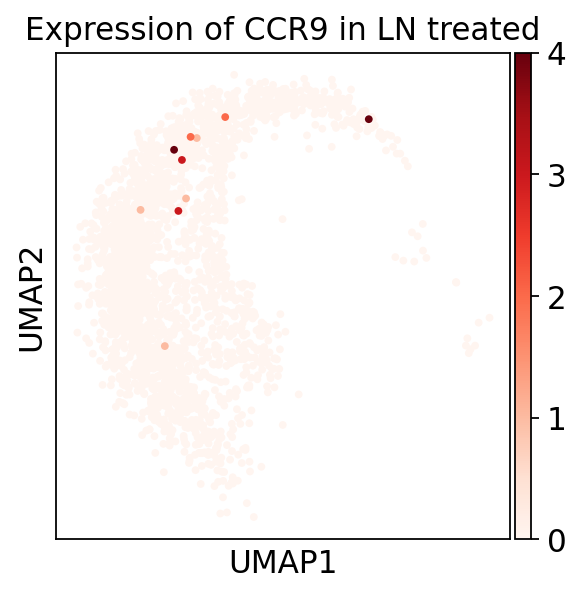

In [104]:
# Create a mask for the specific group
group_mask = adata.obs['groups'] == 'LN treated'

# Plot gene expression for the specific group
sc.pl.umap(adata[group_mask], color='CCR9', title='Expression of CCR9 in LN treated',cmap='Reds',vmin=0,vmax=4)

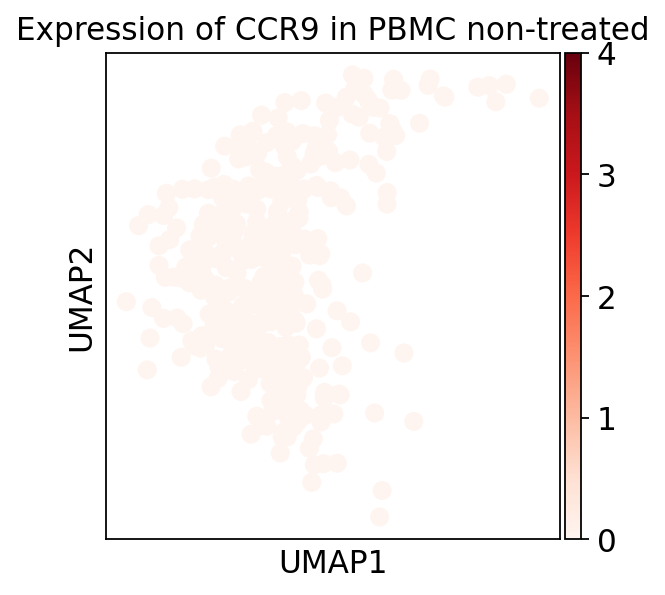

In [109]:
# Create a mask for the specific group
group_mask = adata.obs['groups'] == 'PBMC non-treated'

# Plot gene expression for the specific group
sc.pl.umap(adata[group_mask], color='CCR9', title='Expression of CCR9 in PBMC non-treated',cmap='Reds',vmin=0,vmax=4)

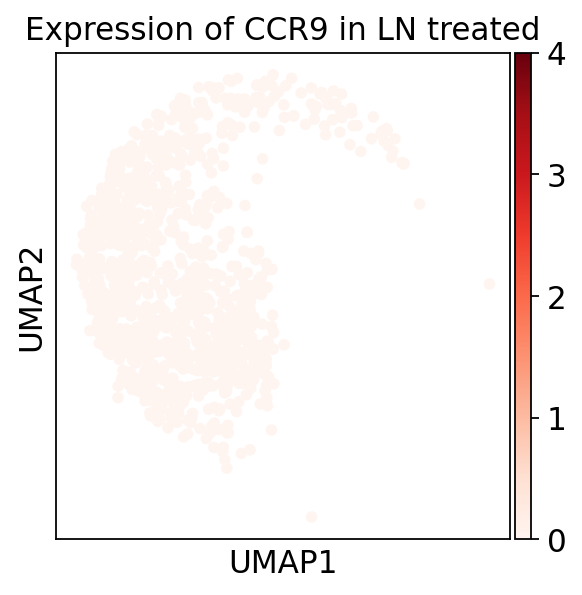

In [106]:
# Create a mask for the specific group
group_mask = adata.obs['groups'] == 'LN non-treated'

# Plot gene expression for the specific group
sc.pl.umap(adata[group_mask], color='CCR9', title='Expression of CCR9 in LN non-treated',cmap='Reds',vmin=0,vmax=4)

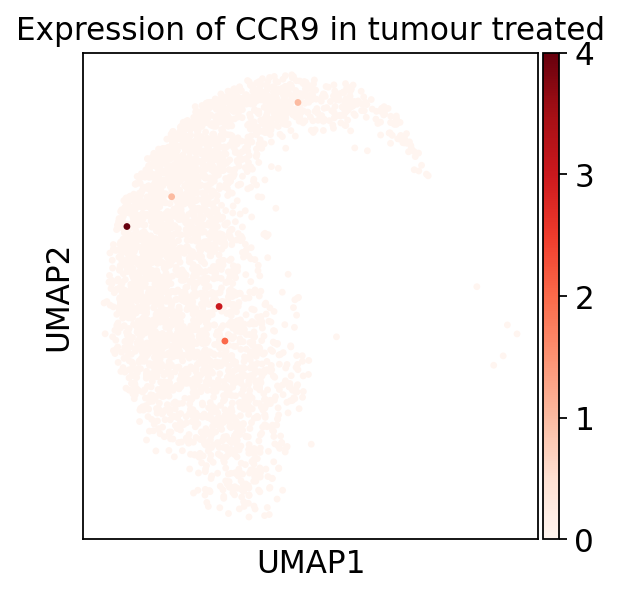

In [107]:
# Create a mask for the specific group
group_mask = adata.obs['groups'] == 'Tumour treated'

# Plot gene expression for the specific group
sc.pl.umap(adata[group_mask], color='CCR9', title='Expression of CCR9 in tumour treated',cmap='Reds',vmin=0,vmax=4)

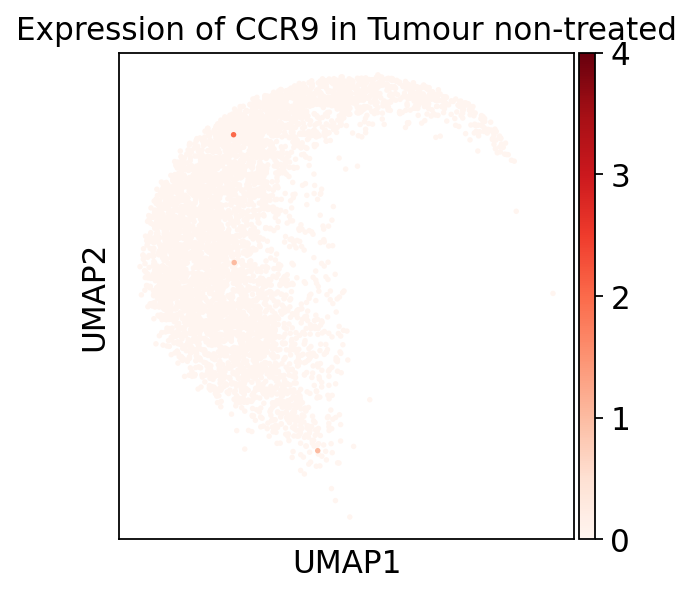

In [108]:
# Create a mask for the specific group
group_mask = adata.obs['groups'] == 'Tumour non-treated'

# Plot gene expression for the specific group
sc.pl.umap(adata[group_mask], color='CCR9', title='Expression of CCR9 in Tumour non-treated',cmap='Reds',vmin=0,vmax=4)

In [110]:
#to convert jupyter notebook in html format
import os
os.system('jupyter nbconvert --to html CCR9_UMAPS.ipynb')

[NbConvertApp] Converting notebook CCR9_UMAPS.ipynb to html
[NbConvertApp] Writing 643185 bytes to CCR9_UMAPS.html


0

In [8]:
ln_treated= adata[adata.obs['groups']=='LN treated']
ln_non_treated = adata[adata.obs['groups'] == 'LN non-treated']
tumour_treated= adata[adata.obs['groups']=='Tumour treated']
tumour_non_treated= adata[adata.obs['groups'] == 'Tumour non-treated']
PBMC_non_treated = adata[adata.obs['groups'] == 'PBMC non-treated']

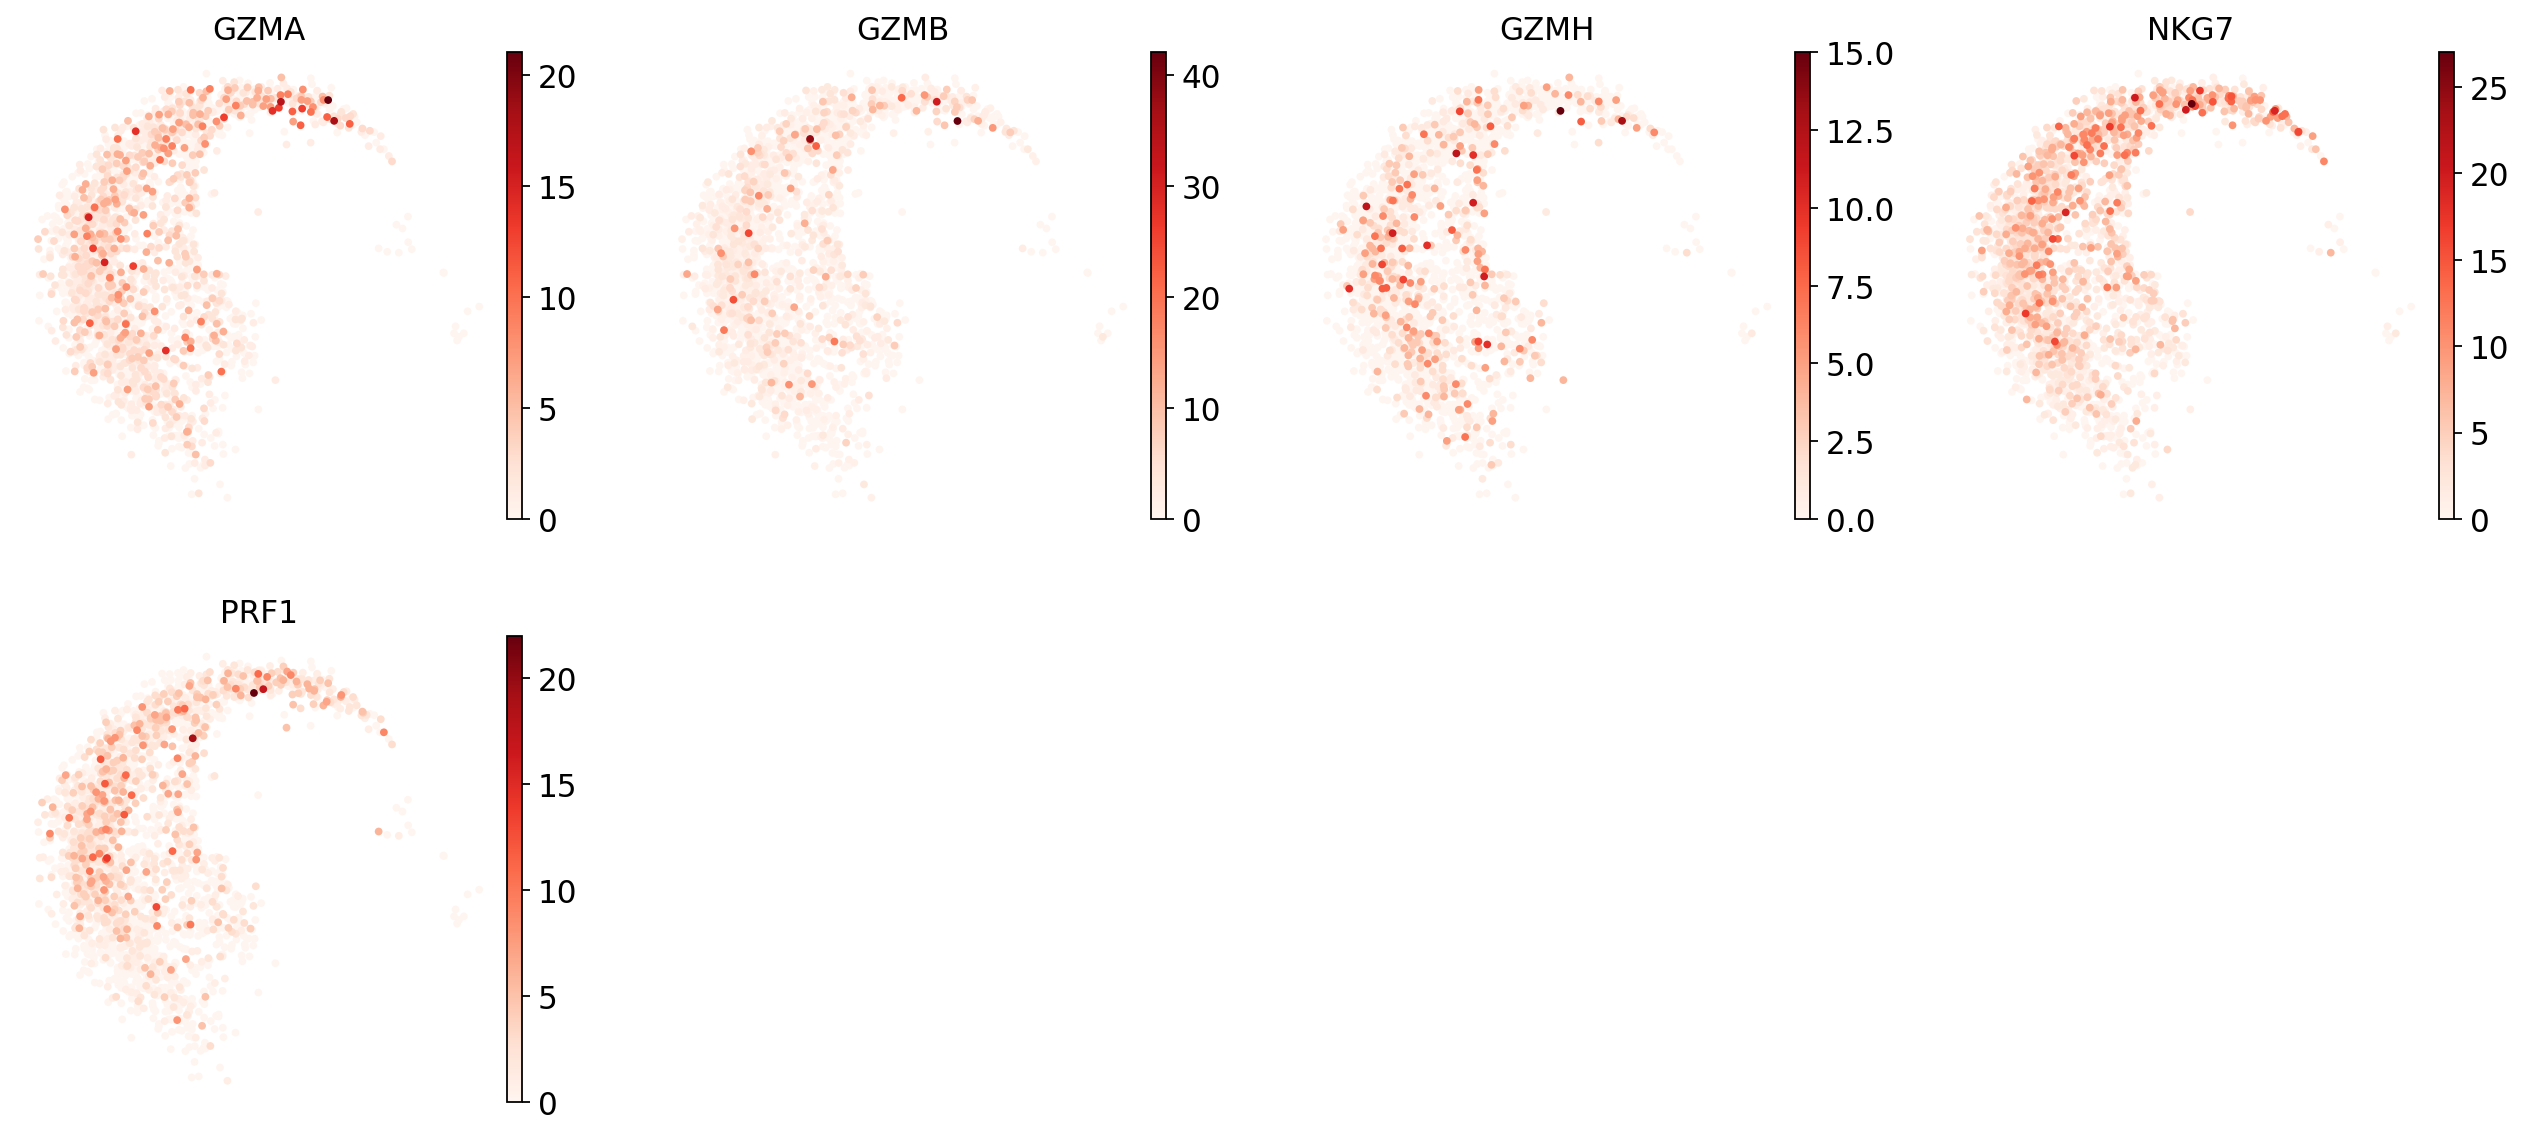

In [112]:
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(ln_treated, color = marker, frameon=False, cmap="Reds")

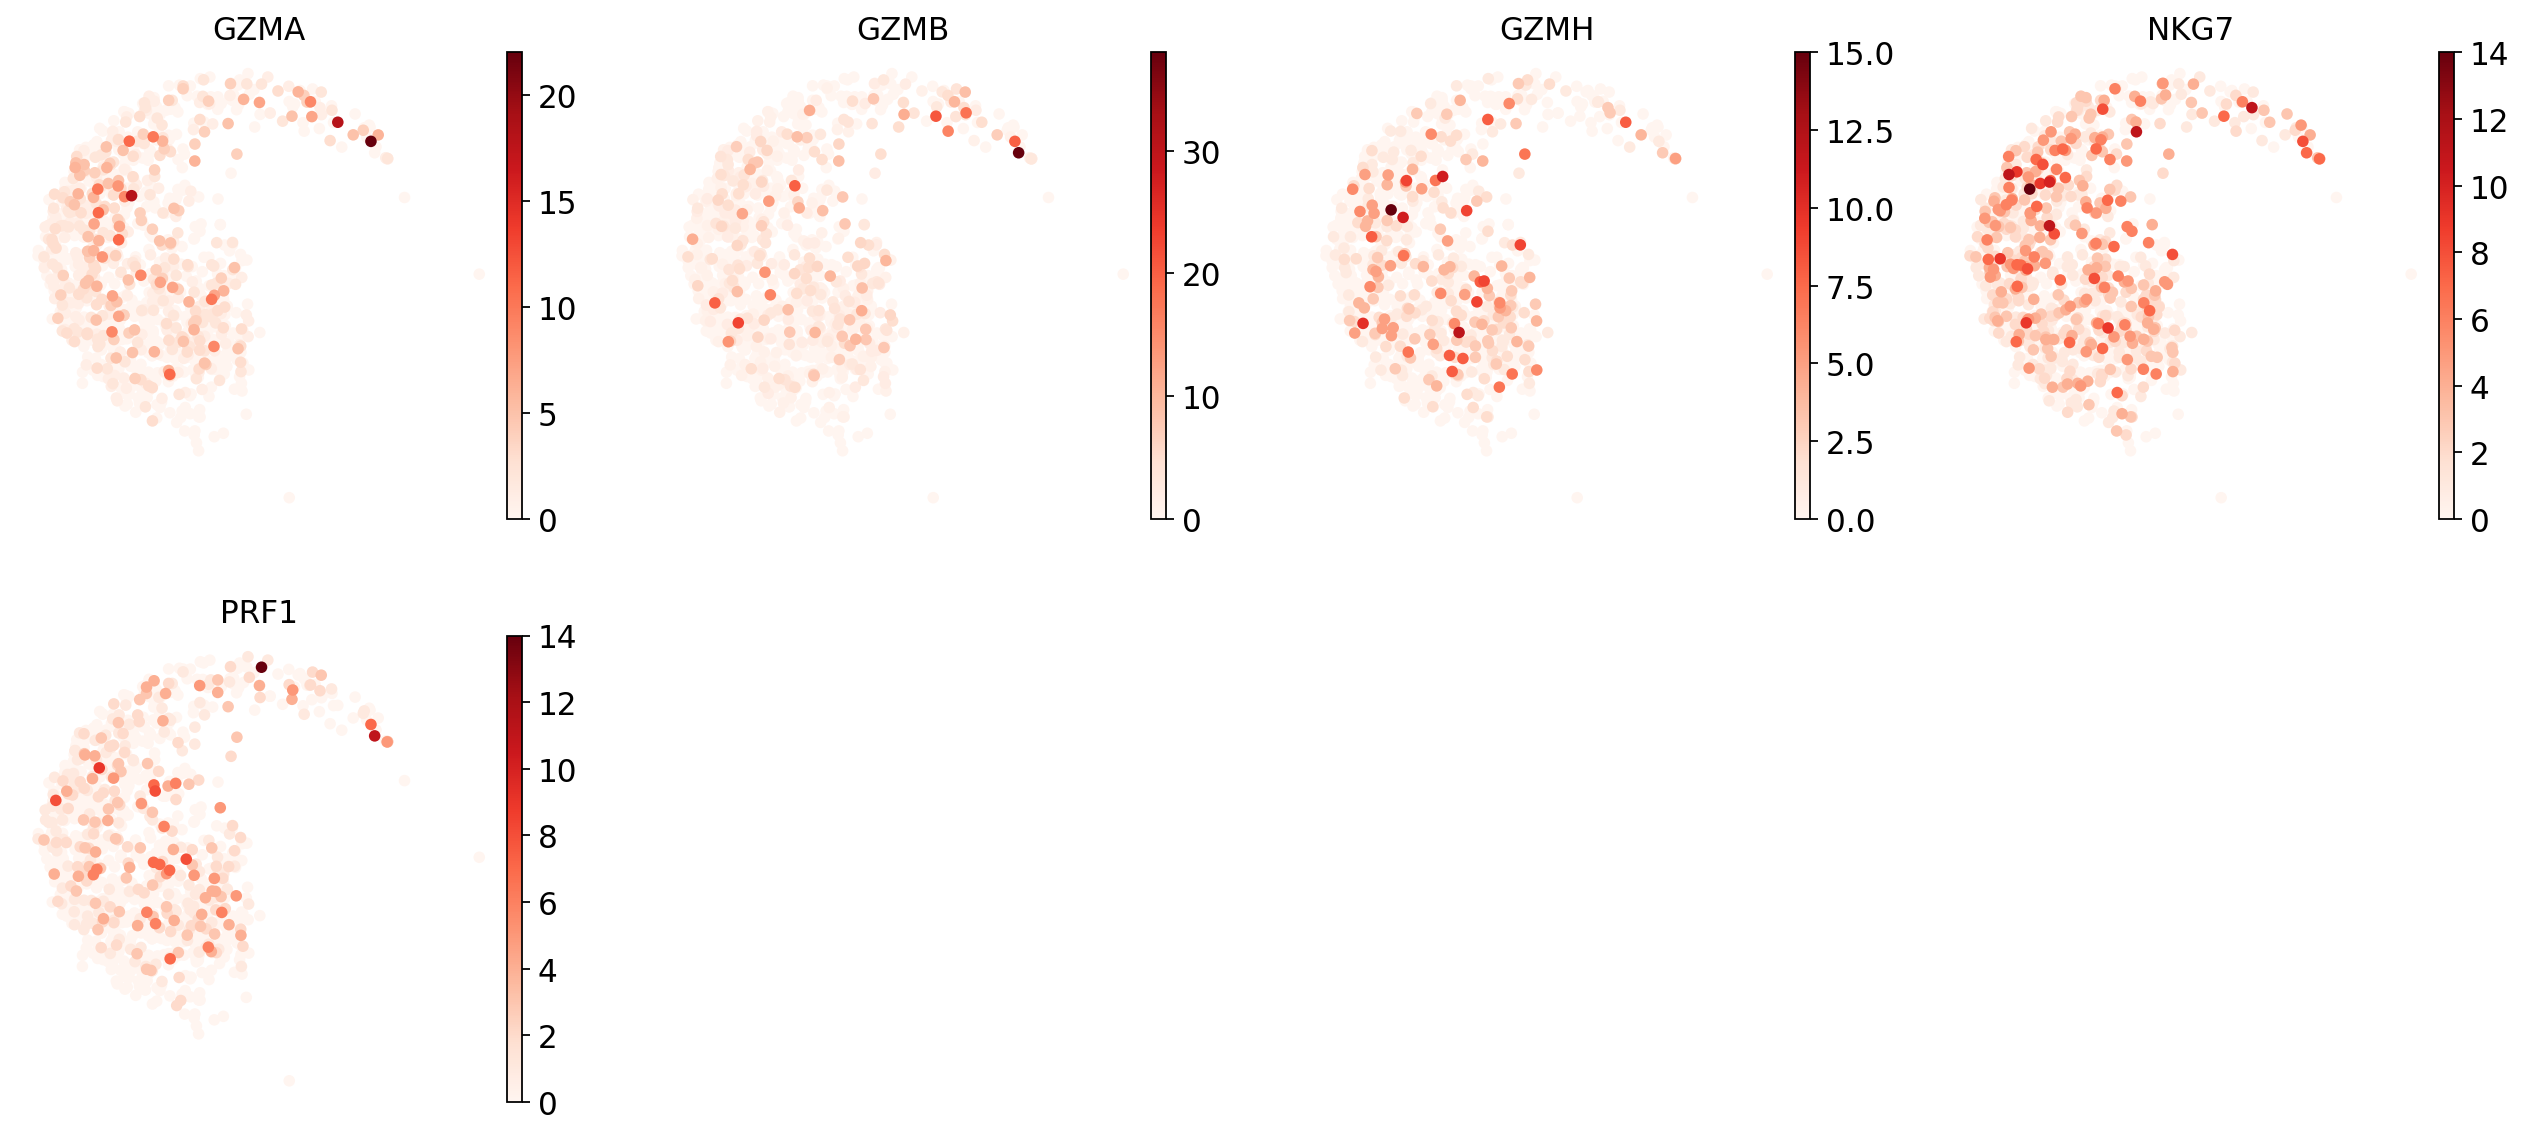

In [114]:
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(ln_non_treated, color = marker, frameon=False, cmap="Reds")

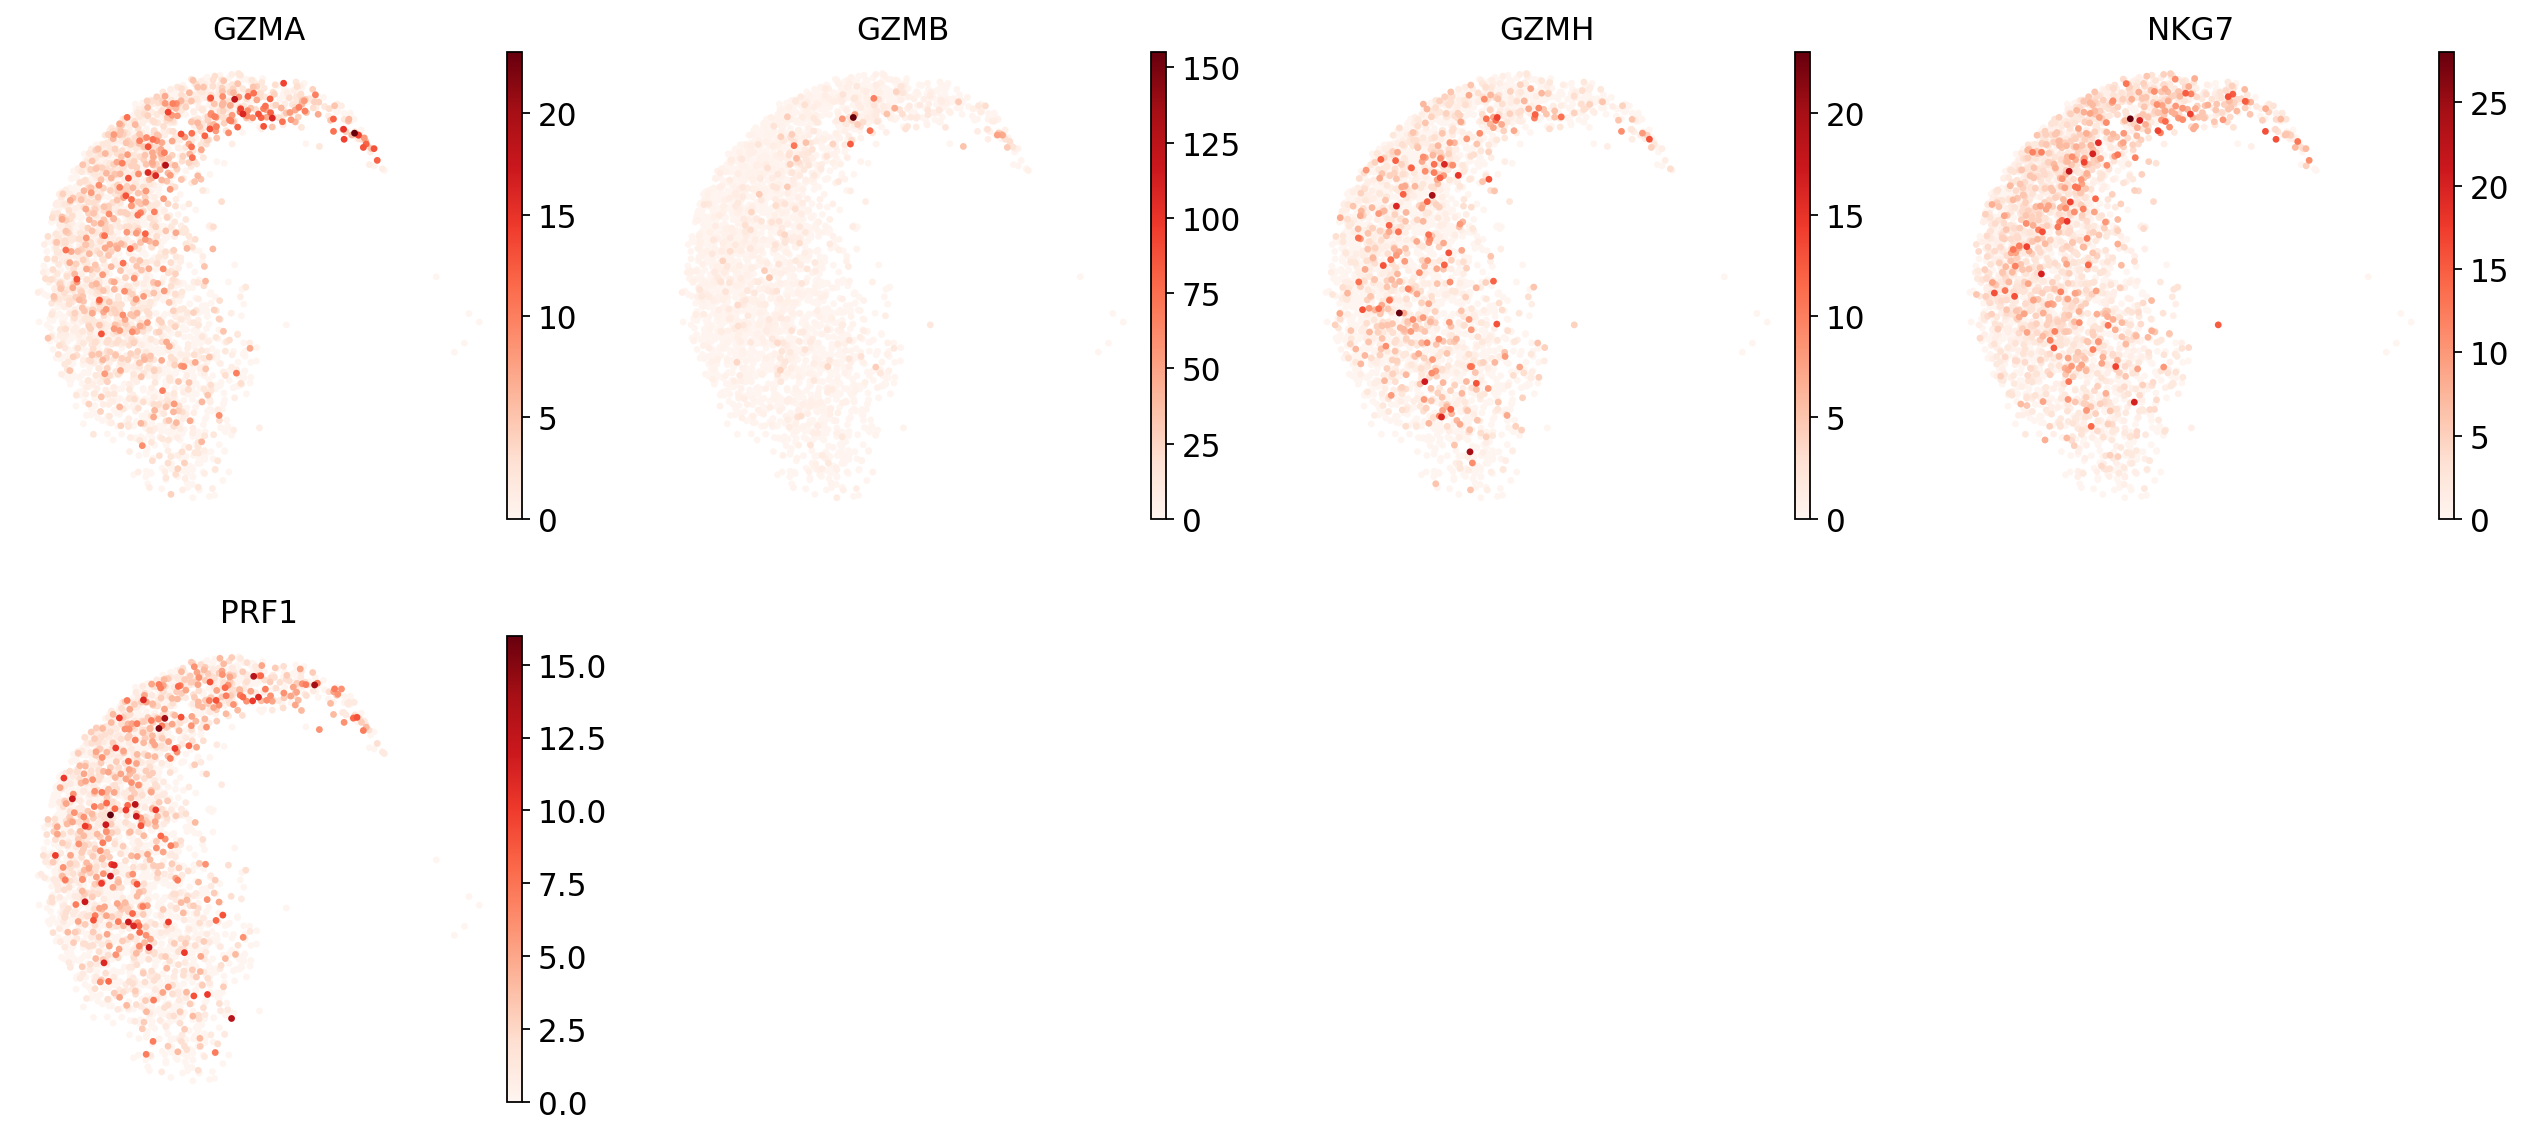

In [116]:
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(tumour_treated, color = marker, frameon=False, cmap="Reds")

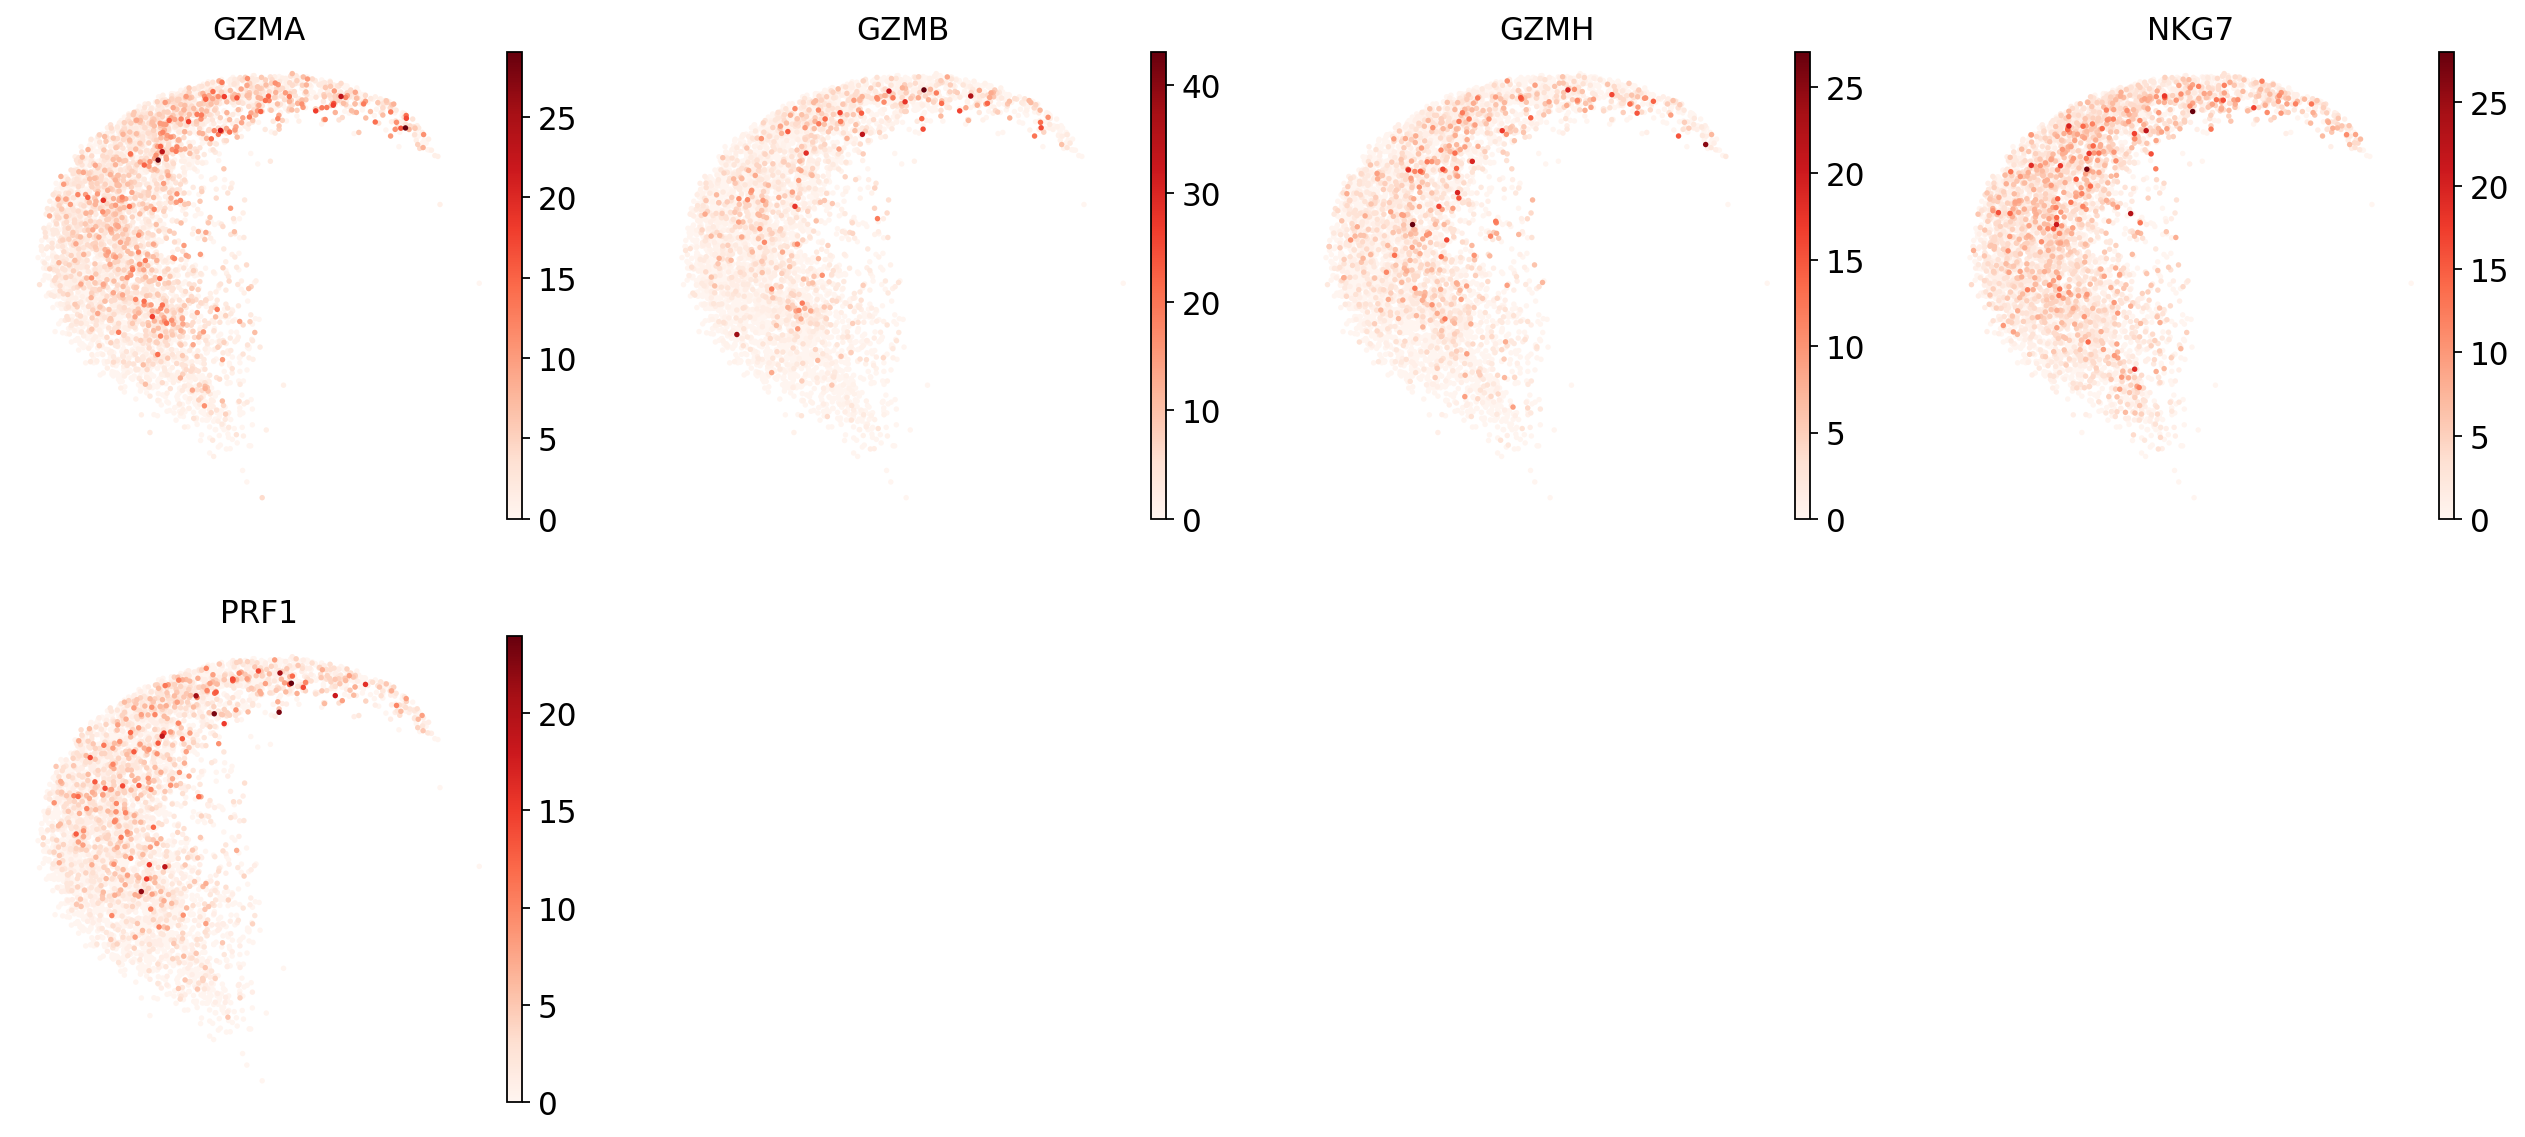

In [117]:
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(tumour_non_treated, color = marker, frameon=False, cmap="Reds")

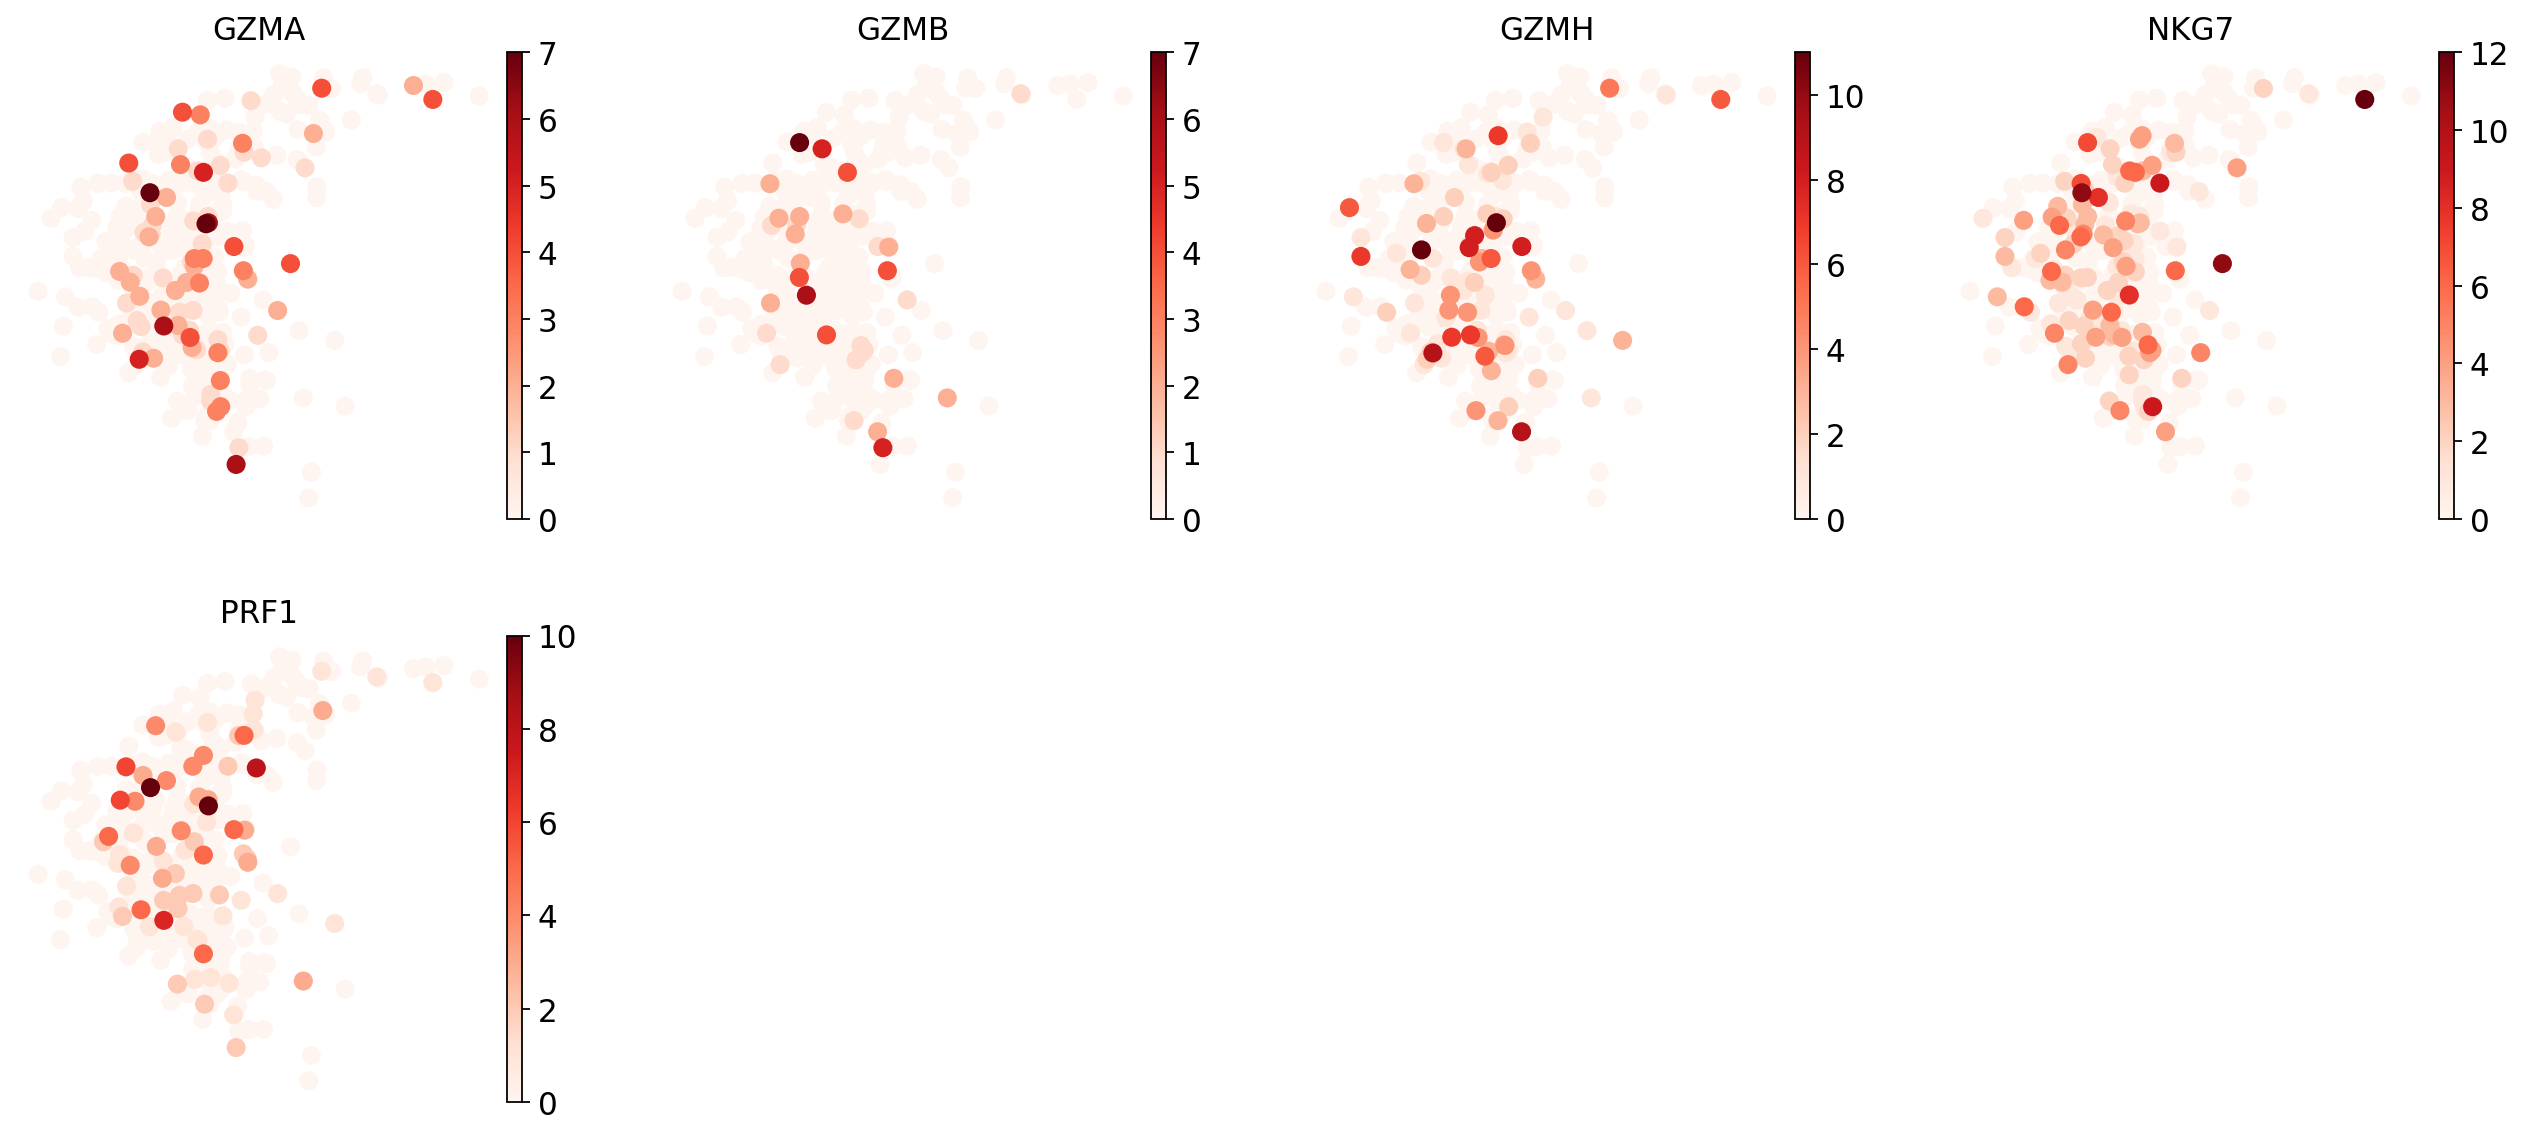

In [118]:
marker = ['GZMA','GZMB','GZMH','NKG7','PRF1']
sc.pl.umap(PBMC_non_treated, color = marker, frameon=False, cmap="Reds")

In [17]:
selected_genes = ['GZMA','GZMB','GZMH','NKG7','PRF1']
adata_subset = adata[:, selected_genes].copy()  


In [18]:
# Assuming you have a 'group' annotation in adata.obs
#sc.pl.violin(adata_subset, 
             #keys=selected_genes, 
             #groupby='groups', 
             #jitter=0.4, 
             #multi_panel=True)


In [19]:
expr_df = adata_subset.to_df()  
expr_df['groups'] = adata.obs['groups'].values 
expr_long = expr_df.melt(id_vars='groups', value_vars=selected_genes, 
                          var_name='gene', value_name='expression')


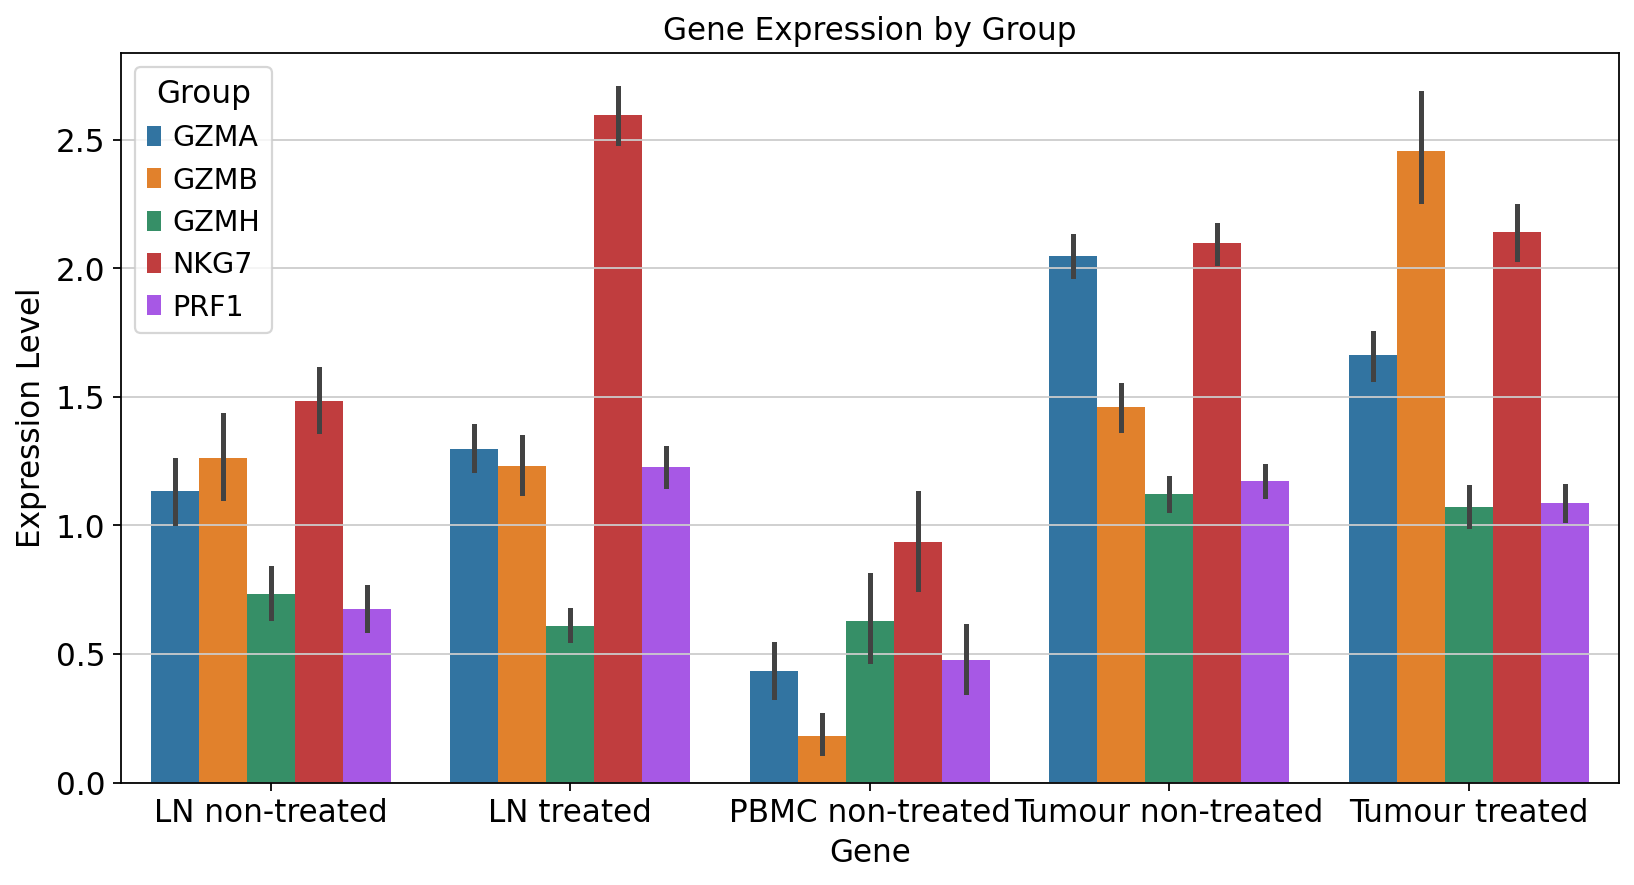

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(x='groups', y='expression', hue='gene', data=expr_long)
plt.title('Gene Expression by Group')
plt.ylabel('Expression Level')
plt.xlabel('Gene')
plt.legend(title='Group')
plt.show()

In [136]:
## you need to select just the ones that select the genes CCR9

In [32]:
barcode=['W542432','W542607','W688809','W844230','WMC0031765','WMC0032342','WMC0035330','WMC0035895',
                'WMC0036352','WMC0037900','WMC0038787','WMC0038874','WMC0109799','WMC286317','WMC286848','WMC286932',
                'WMC286988','WMC289799']

In [33]:
adata = adata[adata.obs_names.isin(barcode)]

In [37]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W542432,7,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W542607,7,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W688809,34,p3,(S)C,4,no-treatment,no-treatment,Tumour non-treated,non-treated
W844230,78,p18,(S)C,3,no-treatment,no-treatment,Tumour non-treated,non-treated
WMC0031765,84,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment
WMC0032342,85,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment
WMC0035330,87,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment
WMC0035895,89,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment
WMC0036352,90,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment
WMC0037900,94,p9,LN,4,"aCTLA4,aPD1",aPD1,LN treated,on-treatment


In [35]:
markers = ['GZMB','NKG7','PRF1']

In [36]:
fig,ax = plt.subplots(figsize=(6,4))
sc.pl.dotplot(adata, markers, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
ax.set_title('CCR9-')
plt.tight_layout()
plt.savefig('dotplot_markers_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_markers_groups.pdf', dpi = 300,bbox_inches='tight')
plt.tight_layout()

plt.show()

In [23]:
import matplotlib
matplotlib.use('Agg')

In [ ]:
fig,ax = plt.subplots(figsize=(4,4))
ax = sc.pl.dotplot(adata, markers, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_markers_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_markers_groups.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(4,4))
ax = sc.pl.dotplot(adata, markers, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_markers_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_markers_groups.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [49]:
selected_genes = ['GZMA','GZMB','GZMH','NKG7','PRF1']
adata_subset = adata[:, selected_genes].copy()  


In [50]:
expr_df = adata_subset.to_df()  
expr_df['groups'] = adata.obs['groups'].values 
expr_long = expr_df.melt(id_vars='groups', value_vars=selected_genes, 
                          var_name='gene', value_name='expression')


In [51]:
expr_df = adata_subset.to_df()  
expr_df['groups'] = adata.obs['groups'].values 
expr_long = expr_df.melt(id_vars='groups', value_vars=selected_genes, 
                          var_name='gene', value_name='expression')


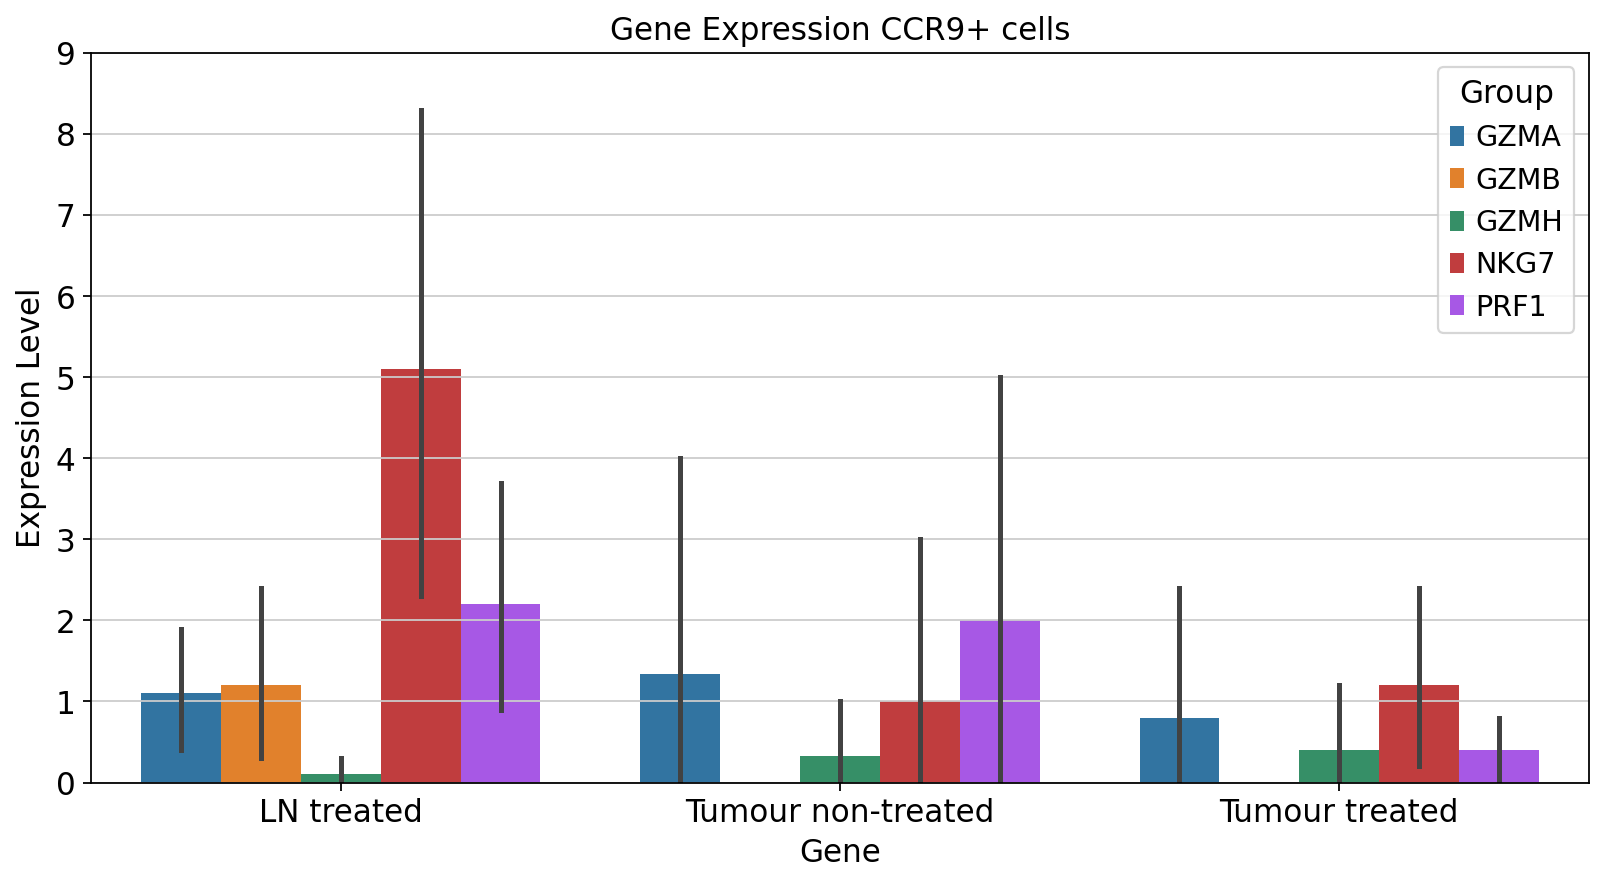

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(x='groups', y='expression', hue='gene', data=expr_long)
plt.title('Gene Expression CCR9+ cells')
plt.ylabel('Expression Level')
plt.xlabel('Gene')
plt.ylim(0,9)
plt.legend(title='Group')
plt.show()


In [54]:
adata = adata[~adata.obs_names.isin(barcode)]

In [55]:
adata

View of AnnData object with n_obs × n_vars = 12118 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [56]:
selected_genes = ['GZMA','GZMB','GZMH','NKG7','PRF1']
adata_subset = adata[:, selected_genes].copy()  


In [57]:
expr_df = adata_subset.to_df()  
expr_df['groups'] = adata.obs['groups'].values 
expr_long = expr_df.melt(id_vars='groups', value_vars=selected_genes, 
                          var_name='gene', value_name='expression')


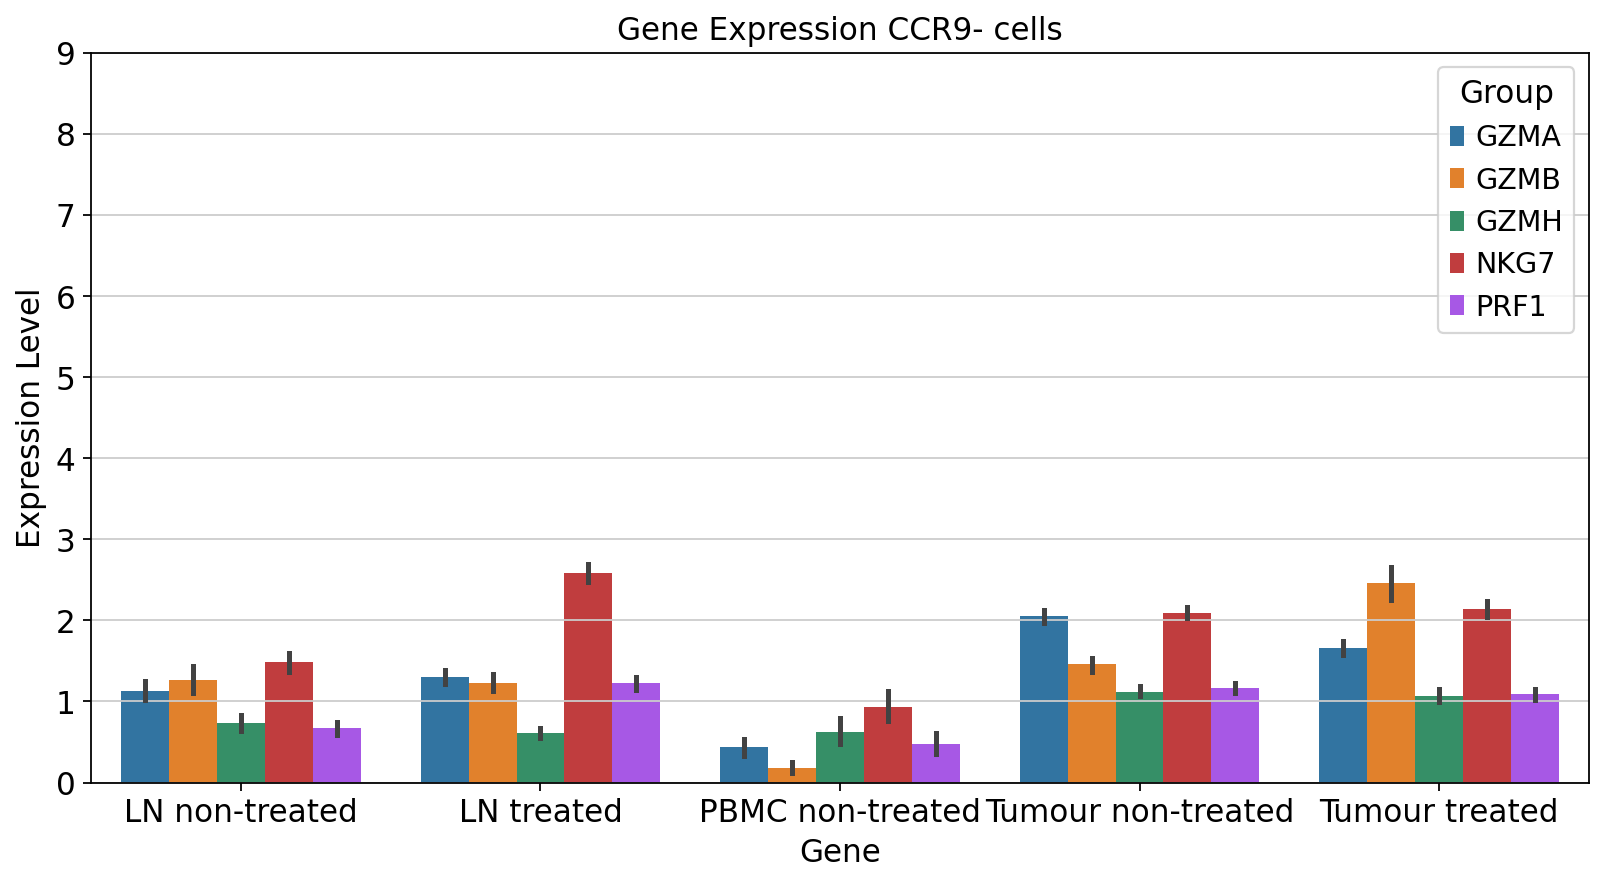

In [59]:
plt.figure(figsize=(12, 6))
sns.barplot(x='groups', y='expression', hue='gene', data=expr_long)
plt.title('Gene Expression CCR9- cells')
plt.ylabel('Expression Level')
plt.ylim(0,9)
plt.xlabel('Gene')
plt.legend(title='Group')
plt.show()


In [67]:
adata = sc.read('/mnt/projects/labs/collab/adata_CD3_CD8.h5')

In [68]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
...,...,...,...,...,...,...,...,...
WMC810381,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810383,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810390,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC
WMC810392,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC


In [69]:
adata = adata[(adata.obs['groups'] == 'LN treated') | (adata.obs['groups'] == 'LN non-treated') | (adata.obs['groups'] == 'Tumour non-treated') 
              | (adata.obs['groups'] == 'Tumour treated')]

In [70]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment
...,...,...,...,...,...,...,...,...
WMC697067,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment
WMC697072,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment
WMC697090,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment
WMC697097,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment


In [71]:
## add column treated/non treated

In [73]:
treated = adata.obs.loc[(adata.obs['groups'] == 'LN treated') | (adata.obs['groups'] == 'Tumour treated'), 'treated'] = 'treated'

In [74]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups,Treated,treated
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,NaN,treated
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,NaN,treated
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,NaN,treated
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,NaN,treated
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,NaN,treated
...,...,...,...,...,...,...,...,...,...,...
WMC697067,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,NaN,treated
WMC697072,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,NaN,treated
WMC697090,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,NaN,treated
WMC697097,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,NaN,treated


In [65]:
non_treated = adata.obs.loc[(adata.obs['groups'] == 'LN non-treated') | (adata.obs['groups'] == 'Tumour non-treated'), 'Treated'] = 'non-treated'

In [66]:
adata.obs.drop('treated',axis=1)

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups,Treated
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,treated
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,treated
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,treated
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,treated
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,treated
...,...,...,...,...,...,...,...,...,...
WMC697067,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,treated
WMC697072,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,treated
WMC697090,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,treated
WMC697097,193,p28,(S)C,4,"aPD1,aCTLA4",no-treatment,Tumour treated,prior treatment,treated


In [260]:
adata

AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [53]:
CCR9_positive_indices = [152, 172, 1285, 4469, 4753, 4942, 5347, 5654, 5840, 6146, 6474, 6522, 6981, 8171, 8427, 8460, 8485, 9169]  # Update with your actual indices
adata.obs['CCR9'] = ['CCR9+' if i in CCR9_positive_indices else 'CCR9-' for i in range(adata.n_obs)]


In [54]:
adata.obs

,samples,patient,tumor_location,disease_stage,prior_treatment,on_treatment,groups,LN-SC groups,CCR9
W461971,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,CCR9-
W461980,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,CCR9-
W461984,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,CCR9-
W461986,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,CCR9-
W461987,1,p2,LN,4,"aPD1,aCTL4",no-treatment,LN treated,prior treatment,CCR9-
...,...,...,...,...,...,...,...,...,...
WMC810381,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC,CCR9-
WMC810383,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC,CCR9-
WMC810390,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC,CCR9-
WMC810392,204,p27-PB,PBMC,4,no-treatment,no-treatment,PBMC non-treated,PBMC,CCR9-


In [56]:
# Define markers and groups
markers = ['GZMB', 'NKG7', 'PRF1']  # Example markers
groups = 'groups'  # Replace with your group

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot for CCR9+ cells
sc.pl.dotplot(adata[adata.obs['CCR9'] == 'CCR9+'], markers, groups,
               dot_max=0.001, dot_min=0, log=True, standard_scale='var', ax=axs[0])
axs[0].set_title('CCR9+ Cells')

# Plot for CCR9- cells
sc.pl.dotplot(adata[adata.obs['CCR9'] == 'CCR9-'], markers, groups,
               dot_max=0.001, dot_min=0, log=True, standard_scale='var', ax=axs[1])
axs[1].set_title('CCR9- Cells')

# Adjust layout
plt.tight_layout()

# Save the figures
plt.savefig('dotplot_markers_groups.png', dpi=300, bbox_inches='tight')
plt.savefig('dotplot_markers_groups.pdf', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()


In [ ]:
fig,ax = plt.subplots(figsize=(6,4))
sc.pl.dotplot(adata, markers, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
ax.set_title('CCR9-')
plt.tight_layout()
plt.savefig('dotplot_markers_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_markers_groups.pdf', dpi = 300,bbox_inches='tight')
plt.tight_layout()

plt.show()

In [263]:
adata

AnnData object with n_obs × n_vars = 12136 × 55765
    obs: 'samples', 'patient', 'tumor_location', 'disease_stage', 'prior_treatment', 'on_treatment', 'groups', 'LN-SC groups', 'CCR9'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [264]:
markers = ['GZMB','NKG7','PRF1']

In [ ]:
fig,ax = plt.subplots(figsize=(4,4))
ax = sc.pl.dotplot(adata, markers, "groups", dot_max = 0.001, dot_min = 0, log = True,standard_scale='var',ax=ax)
plt.savefig('dotplot_genes_groups.png', dpi = 300,bbox_inches='tight')
plt.savefig('dotplot_genes_groups.pdf', dpi = 300,bbox_inches='tight')
plt.show()

In [235]:
## 'GZMA','GZMB','GZMH','NKG7','PRF1'

In [250]:
gene_name = 'GZMA'
gene_expression = adata[:, gene_name].X.flatten()  # Use .raw if you're interested in raw counts

# Create a DataFrame
gene_data = pd.DataFrame({
    'Expression': gene_expression,
    'CCR9': adata.obs['CCR9'],
    'Treated':adata.obs['Treated']
})


In [251]:
gene_data

,Expression,CCR9,Treated
W461971,2,CCR9-,treated
W461980,7,CCR9-,treated
W461984,5,CCR9-,treated
W461986,3,CCR9-,treated
W461987,0,CCR9-,treated
...,...,...,...
WMC697067,0,CCR9-,treated
WMC697072,0,CCR9-,treated
WMC697090,3,CCR9-,treated
WMC697097,4,CCR9-,treated


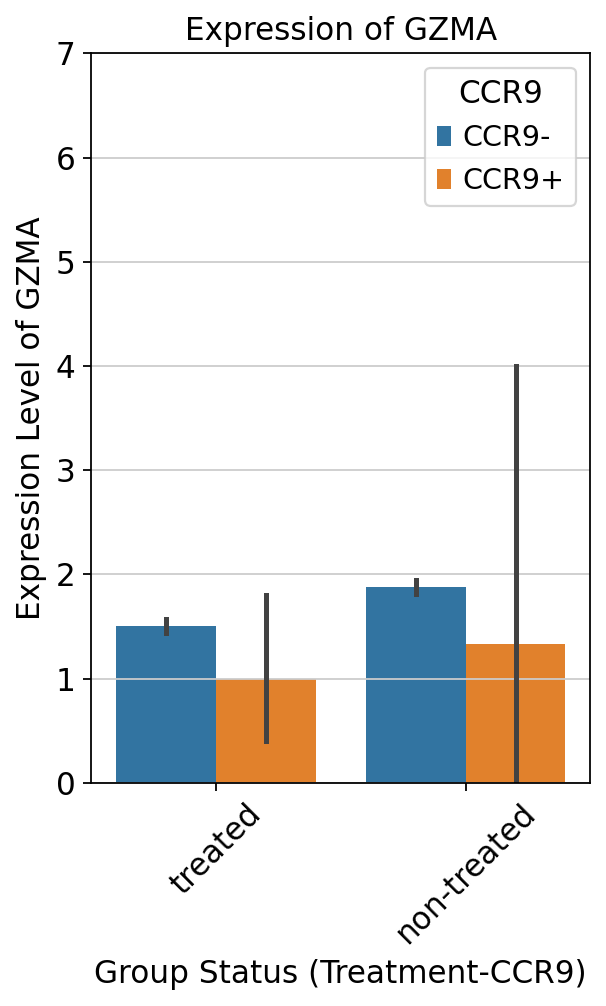

In [252]:
plt.figure(figsize=(4, 6))
sns.barplot(x='Treated', y='Expression', data=gene_data, hue='CCR9')
plt.title('Expression of GZMA')
plt.xlabel('Group Status (Treatment-CCR9)')
plt.ylabel('Expression Level of GZMA')
plt.ylim(0,7)
plt.xticks(rotation=45)
plt.savefig('expression_GZMA.png', dpi = 300,bbox_inches='tight')
plt.savefig('expression_GZMA.pdf', dpi = 300,bbox_inches='tight')
plt.show()


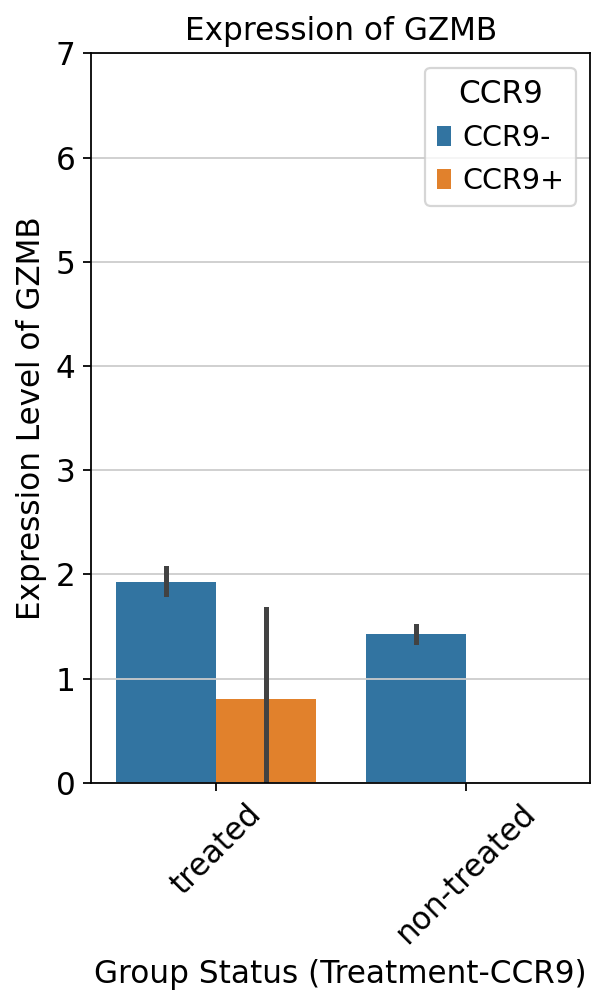

In [253]:
gene_name = 'GZMB'
gene_expression = adata[:, gene_name].X.flatten()  # Use .raw if you're interested in raw counts

# Create a DataFrame
gene_data = pd.DataFrame({
    'Expression': gene_expression,
    'CCR9': adata.obs['CCR9'],
    'Treated':adata.obs['Treated']
})

plt.figure(figsize=(4, 6))
sns.barplot(x='Treated', y='Expression', data=gene_data, hue='CCR9')
plt.title('Expression of GZMB')
plt.xlabel('Group Status (Treatment-CCR9)')
plt.ylabel('Expression Level of GZMB')
plt.ylim(0,7)
plt.xticks(rotation=45)
plt.savefig('expression_GZMB.png', dpi = 300,bbox_inches='tight')
plt.savefig('expression_GZMB.pdf', dpi = 300,bbox_inches='tight')
plt.show()


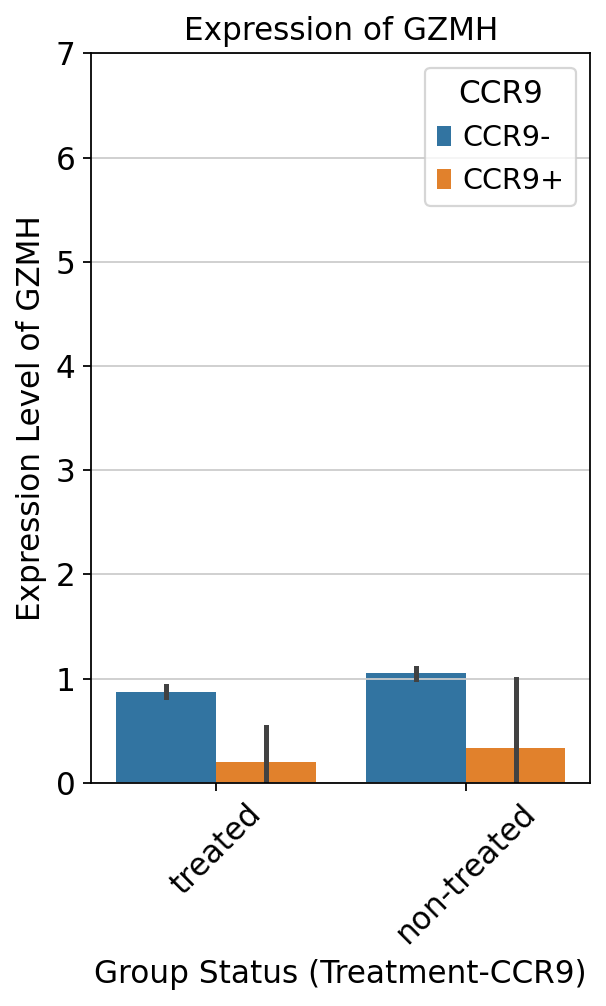

In [254]:
gene_name = 'GZMH'
gene_expression = adata[:, gene_name].X.flatten()  # Use .raw if you're interested in raw counts

# Create a DataFrame
gene_data = pd.DataFrame({
    'Expression': gene_expression,
    'CCR9': adata.obs['CCR9'],
    'Treated':adata.obs['Treated']
})

plt.figure(figsize=(4, 6))
sns.barplot(x='Treated', y='Expression', data=gene_data, hue='CCR9')
plt.title('Expression of GZMH')
plt.xlabel('Group Status (Treatment-CCR9)')
plt.ylabel('Expression Level of GZMH')
plt.ylim(0,7)
plt.xticks(rotation=45)
plt.savefig('expression_GZMH.png', dpi = 300,bbox_inches='tight')
plt.savefig('expression_GZMH.pdf', dpi = 300,bbox_inches='tight')
plt.show()

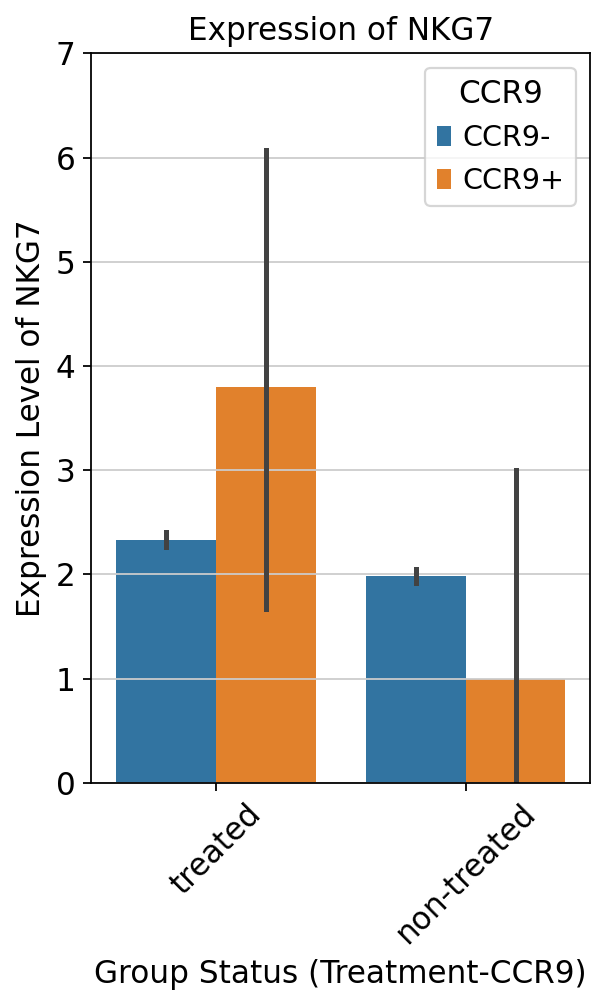

In [255]:
gene_name = 'NKG7'
gene_expression = adata[:, gene_name].X.flatten()  # Use .raw if you're interested in raw counts

# Create a DataFrame
gene_data = pd.DataFrame({
    'Expression': gene_expression,
    'CCR9': adata.obs['CCR9'],
    'Treated':adata.obs['Treated']
})

plt.figure(figsize=(4, 6))
sns.barplot(x='Treated', y='Expression', data=gene_data, hue='CCR9')
plt.title('Expression of NKG7')
plt.xlabel('Group Status (Treatment-CCR9)')
plt.ylabel('Expression Level of NKG7')
plt.ylim(0,7)
plt.xticks(rotation=45)
plt.savefig('expression_NKG7.png', dpi = 300,bbox_inches='tight')
plt.savefig('expression_NKG7.pdf', dpi = 300,bbox_inches='tight')
plt.show()

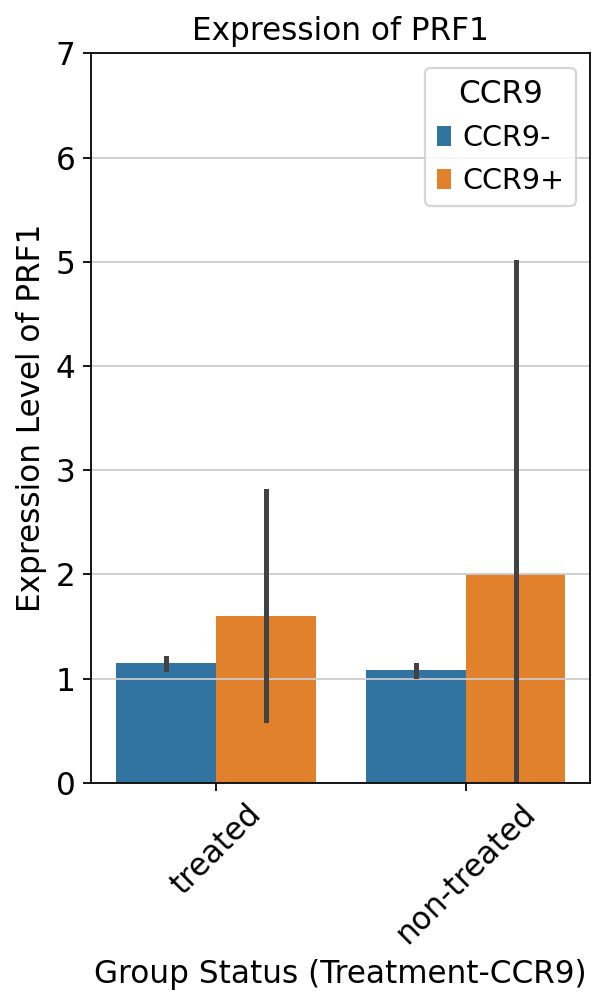

In [256]:
gene_name = 'PRF1'
gene_expression = adata[:, gene_name].X.flatten()  # Use .raw if you're interested in raw counts

# Create a DataFrame
gene_data = pd.DataFrame({
    'Expression': gene_expression,
    'CCR9': adata.obs['CCR9'],
    'Treated':adata.obs['Treated']
})

plt.figure(figsize=(4, 6))
sns.barplot(x='Treated', y='Expression', data=gene_data, hue='CCR9')
plt.title('Expression of PRF1')
plt.xlabel('Group Status (Treatment-CCR9)')
plt.ylabel('Expression Level of PRF1')
plt.ylim(0,7)
plt.xticks(rotation=45)
plt.savefig('expression_PRF1.png', dpi = 300,bbox_inches='tight')
plt.savefig('expression_PRF1.pdf', dpi = 300,bbox_inches='tight')
plt.show()